# AT&T Modèle CNN Maison

In [1]:
import io
import re
import string
import tensorflow as tf
import tqdm
import os
import shutil
import pandas as pd

from tensorflow.keras import Model
from tensorflow.keras.layers import Dot, Embedding, Flatten
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

import warnings
warnings.filterwarnings('ignore')


2025-09-02 16:06:29.278350: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import chardet
import requests

url = "https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Deep+Learning/project/spam.csv"
response = requests.get(url)

# Vérifier si la requête a réussi
if response.status_code == 200:
    rawdata = response.content  # Obtenir les données en bytes
    result = chardet.detect(rawdata[:100000])  # Détecter l'encodage
    print(result)
else:
    print("Échec du téléchargement du fichier :", response.status_code)

{'encoding': 'Windows-1252', 'confidence': 0.7272080023536335, 'language': ''}


In [3]:
df = pd.read_csv("https://full-stack-bigdata-datasets.s3.eu-west-3.amazonaws.com/Deep+Learning/project/spam.csv",encoding='Windows-1252')

In [4]:
df

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


In [5]:
# Préparation des données et suppression des colonnes vides
df = df[['v1', 'v2']]
df = df.rename(columns={'v1': 'Target', 'v2': 'SMS'})
df['Target'] = df['Target'].replace(to_replace=["ham"], value=0)
df['Target'] = df['Target'].replace(to_replace=["spam"], value=1)

In [6]:
# Preprocessing NLP
import spacy
import numpy as np
import en_core_web_sm
from spacy.lang.en.stop_words import STOP_WORDS as EN_STOP_WORDS
# Charger spaCy (désactiver parser/ner pour la vitesse)
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

# Filtrer les valeurs non-string si nécessaire
mask = df["SMS"].apply(lambda x: isinstance(x, str) and x.strip() != "")
df = df.loc[mask].copy()

# Nettoyage avancé du texte

In [7]:
import re
import emoji

def clean_text_spam_optimized(text):
    if not isinstance(text, str) or not text.strip():
        return ""

    text = re.sub(r"\s+", " ", text.strip())

    # URLs raccourcies (corrigé pour capturer "http:shor.lu/122")
    text = re.sub(r"(?:https?://)?(?:bit\.ly|tinyurl\.com|goo\.gl|is\.gd|shor\.lu)/[a-zA-Z0-9]+", " <SHORTURL> ", text, flags=re.IGNORECASE)
    # Autres URLs
    text = re.sub(r"https?://\S+|www\.\S+", " <URL> ", text, flags=re.IGNORECASE)

    # Emails
    text = re.sub(r"\b[\w.-]+@[\w.-]+\.\w+\b", " <EMAIL> ", text)

    # Numéros de téléphone
    text = re.sub(r"\b(?:\+?\d{1,3}[-. ]?)?\(?\d{3}\)?[-. ]?\d{3}[-. ]?\d{4}\b", " <PHONE> ", text)
    # Nombres
    text = re.sub(r"\b\d+\b", " <NUM> ", text)  # Espaces ajoutés

    # Hashtags et mentions
    text = re.sub(r"#\w+", " <HASHTAG> ", text)
    text = re.sub(r"@\w+", " <MENTION> ", text)

    # Mots-clés spam (espaces ajoutés)
    spam_keywords = r"(?:urgent|immediate|now|asap|verify|confirm|claim|click\s*here|free|winner|prize|limited|offer|congratulations|guaranteed|win|won)"
    text = re.sub(spam_keywords, " <SPAMKEY> ", text, flags=re.IGNORECASE)

    # Redirections
    text = re.sub(r"(?:redirected|redirecting)\s*in\s*\d+\s*seconds", " <REDIRECT> ", text, flags=re.IGNORECASE)

    # Emojis
    text = emoji.demojize(text)

    # Caractères spéciaux utiles
    text = re.sub(r"[^\w\s'!\?\$#%&*+\-=@.|~`€£¥]", "", text)

    # Normalisation finale des espaces
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

# Appliquer au DataFrame
df["SMS_Clean"] = df["SMS"].astype(str).map(clean_text_spam_optimized)

In [8]:
df

,Target,SMS,SMS_Clean
0,0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy.. available only i...
1,0,Ok lar... Joking wif u oni...,ok lar... joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,spamkey entry in num a wkly comp to spamkey fa...
3,0,U dun say so early hor... U c already then say...,u dun say so early hor... u c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro...",nah i don't think he goes to usf he lives arou...
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,this is the 2nd time we have tried num contact...
5568,0,Will Ì_ b going to esplanade fr home?,will ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s...",pity * was in mood for that. so...any other su...
5570,0,The guy did some bitching but I acted like i'd...,the guy did some bitching but i acted like i'd...


In [9]:
def lemmatize_pipe_spam(texts, batch_size=2000):
    out = []
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=1):
        tokens = [
            token.lemma_.lower() if token.text.lower() not in ["<url>", "<shorturl>", "<phone>", "<num>", "<redirect>"] else token.text.lower()
            for token in doc
            if (token.is_alpha or token.text in ["<url>", "<shorturl>", "<phone>", "<num>", "<redirect>"]) and not token.is_stop and token.text.strip() != ""
        ]
        out.append(" ".join(tokens))
    return out

df["SMS_Clean"] = lemmatize_pipe_spam(df["SMS_Clean"].tolist())

In [10]:
df

,Target,SMS,SMS_Clean
0,0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis n great wor...
1,0,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,spamkey entry num wkly comp spamkey fa cup fin...
3,0,U dun say so early hor... U c already then say...,u dun early hor u c
4,0,"Nah I don't think he goes to usf, he lives aro...",nah think go usf live
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,time try num contact u spamkey num pound spamk...
5568,0,Will Ì_ b going to esplanade fr home?,ì b go esplanade fr home
5569,0,"Pity, * was in mood for that. So...any other s...",pity mood suggestion
5570,0,The guy did some bitching but I acted like i'd...,guy bitching act like interested buy week give...


## Preprocessing

In [11]:

# 🔥 Train Split Test
from sklearn.model_selection import train_test_split
X_train_text, X_val_text, y_train, y_val = train_test_split(
    df.SMS_Clean, df.Target, test_size=0.3, random_state=42, stratify=df["Target"]
)

# Tokenization UNIQUEMENT sur les données d'entraînement

import tensorflow as tf

tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=10000, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text.tolist())

X_train_encoded = tokenizer.texts_to_sequences(X_train_text.tolist())
X_val_encoded = tokenizer.texts_to_sequences(X_val_text.tolist())

# Optimal padding length (95th percentile)
lengths = [len(seq) for seq in X_train_encoded]
if len(lengths) == 0:
    raise ValueError("Aucune séquence d'entraînement après tokenization.")
max_len = int(np.percentile(lengths, 95))
max_len = max(1, max_len)   # au moins 1

X_train_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_train_encoded, maxlen=max_len, padding='post', truncating='post'
)
X_val_pad = tf.keras.preprocessing.sequence.pad_sequences(
    X_val_encoded, maxlen=max_len, padding='post', truncating='post'
)


# Oversampling contrôlé avec option : # "full", "partial", "factor", "none"

In [ ]:
from sklearn.utils import resample


STRATEGY = "partial"   
TARGET_RATIO = 0.5
FACTOR = 5.0

y_train_array = np.asarray(y_train)
ham_mask = y_train_array == 0
spam_mask = y_train_array == 1

ham_data, spam_data = X_train_pad[ham_mask], X_train_pad[spam_mask]
ham_labels, spam_labels = y_train_array[ham_mask], y_train_array[spam_mask]

print(f"📊 Original: {len(ham_data)} HAM, {len(spam_data)} SPAM")

is_spam_minority = len(spam_data) < len(ham_data)
minority_count = min(len(ham_data), len(spam_data))
majority_count = max(len(ham_data), len(spam_data))

if STRATEGY == "full":
    target_minority = majority_count
elif STRATEGY == "partial":
    if not (0 < TARGET_RATIO < 1):
        raise ValueError("TARGET_RATIO must be in (0,1) for partial strategy")
    target_minority = int(TARGET_RATIO * majority_count / (1 - TARGET_RATIO))
elif STRATEGY == "factor":
    target_minority = int(minority_count * FACTOR)
else:
    target_minority = minority_count

# Gérer le cas où minority_count == 0
if minority_count == 0 or STRATEGY == "none" or target_minority <= minority_count:
    X_train_balanced = X_train_pad
    y_train_balanced = y_train_array
else:
    if is_spam_minority:
        spam_resampled = resample(spam_data, replace=True, n_samples=target_minority, random_state=42)
        labels_resampled = resample(spam_labels, replace=True, n_samples=target_minority, random_state=42)
        X_comb = np.vstack([ham_data, spam_resampled])
        y_comb = np.concatenate([ham_labels, labels_resampled])
    else:
        ham_resampled = resample(ham_data, replace=True, n_samples=target_minority, random_state=42)
        labels_resampled = resample(ham_labels, replace=True, n_samples=target_minority, random_state=42)
        X_comb = np.vstack([ham_resampled, spam_data])
        y_comb = np.concatenate([labels_resampled, spam_labels])

    # Shuffle final pour mélanger les classes
    rng = np.random.RandomState(42)
    idx = rng.permutation(len(y_comb))
    X_train_balanced = X_comb[idx]
    y_train_balanced = y_comb[idx]

# Résultats
final_ham = np.sum(y_train_balanced == 0)
final_spam = np.sum(y_train_balanced == 1)
total = len(y_train_balanced)
print(f"📊 Final: {final_ham} HAM ({final_ham/total*100:.1f}%), {final_spam} SPAM ({final_spam/total*100:.1f}%)")

if STRATEGY != "none" and minority_count > 0 and target_minority > minority_count:
    increase = (target_minority - minority_count) / minority_count * 100
    minority_class = "SPAM" if is_spam_minority else "HAM"
    print(f"📈 {minority_class} augmenté de {increase:.1f}% (×{target_minority/minority_count:.1f})")

# --- 7) Datasets TF et modèle ---

📊 Original: 3377 HAM, 523 SPAM
📊 Final: 3377 HAM (50.0%), 3377 SPAM (50.0%)
📈 SPAM augmenté de 545.7% (×6.5)


In [13]:
tokenizer.num_words

10000

# Modèle CNN 

In [14]:
# --- 7) Datasets TF et modèle ---
BATCH_SIZE = 32
BUFFER_SIZE = len(y_train_balanced) if len(y_train_balanced) < 10000 else 1000

X_train_balanced = X_train_balanced.astype(np.int32)
y_train_balanced = y_train_balanced.astype(np.int32)

train_batch = tf.data.Dataset.from_tensor_slices((X_train_balanced, y_train_balanced)) \
    .shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_batch = tf.data.Dataset.from_tensor_slices((X_val_pad.astype(np.int32), np.asarray(y_val).astype(np.int32))) \
    .batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

vocab_size = min(tokenizer.num_words, len(tokenizer.word_index) + 1) if tokenizer.num_words else (len(tokenizer.word_index) + 1)

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy",
             tf.keras.metrics.Precision(name="precision"),
             tf.keras.metrics.Recall(name="recall"),
             tf.keras.metrics.AUC(name="auc")]
)


## Callback pour contrôler le RUN

In [15]:
# Callbacks avancés pour l'entraînement
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os

# Créer le dossier pour sauvegarder les modèles
os.makedirs('models', exist_ok=True)

monitor_metric = 'val_auc'

checkpoint = ModelCheckpoint(
    filepath='models/best_spam_model.h5',
    monitor=monitor_metric,
    mode='max',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor=monitor_metric,
    mode='max',
    patience=50,
    restore_best_weights=True,
    verbose=1,
    min_delta=1e-5
)

reduce_lr = ReduceLROnPlateau(
    monitor=monitor_metric,
    mode='max',
    factor=0.5,
    patience=5,
    min_lr=1e-7,
    verbose=1,
    cooldown=3
)
# Liste des callbacks
callbacks_list = [checkpoint,
                  early_stopping, 
                  reduce_lr]

print("📋 Configuration des callbacks:")
print(f"  • ModelCheckpoint: Sauvegarde dans 'models/best_spam_model.h5' (métrique: val_auc)")
print(f"  • EarlyStopping: Patience de 15 epochs (métrique: val_loss)")
print(f"  • ReduceLROnPlateau: Réduction LR /2 après 7 epochs sans amélioration")

# Entraînement avec callbacks
history = model.fit(train_batch, 
                    epochs=200, 
                    validation_data=val_batch,
                    callbacks=callbacks_list,
                    verbose=1)

print("\n🎯 Entraînement terminé!")
print("📁 Meilleur modèle sauvegardé dans: 'models/best_spam_model.h5'")

# Charger le meilleur modèle pour évaluation finale
print("\n🔄 Chargement du meilleur modèle pour évaluation...")
best_model = tf.keras.models.load_model('models/best_spam_model.h5')

# Évaluation finale sur les données de validation
print("\n📊 Évaluation du meilleur modèle:")
final_results = best_model.evaluate(val_batch, verbose=0)
metrics_names = best_model.metrics_names
for name, value in zip(metrics_names, final_results):
    print(f"  • {name}: {value:.4f}")

📋 Configuration des callbacks:
  • ModelCheckpoint: Sauvegarde dans 'models/best_spam_model.h5' (métrique: val_auc)
  • EarlyStopping: Patience de 15 epochs (métrique: val_loss)
  • ReduceLROnPlateau: Réduction LR /2 après 7 epochs sans amélioration
Epoch 1/200


200/212 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7243 - auc: 0.7671 - loss: 0.6778 - precision: 0.7479 - recall: 0.7098
Epoch 1: val_auc improved from None to 0.94170, saving model to models/best_spam_model.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7995 - auc: 0.8699 - loss: 0.6480 - precision: 0.8501 - recall: 0.7273 - val_accuracy: 0.9121 - val_auc: 0.9417 - val_loss: 0.5161 - val_precision: 0.6421 - val_recall: 0.7768 - learning_rate: 1.0000e-04
Epoch 2/200
203/212 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8680 - auc: 0.9279 - loss: 0.5142 - precision: 0.9343 - recall: 0.7929
Epoch 2: val_auc improved from 0.94170 to 0.96116, saving model to models/best_spam_model.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8801 - auc: 0.9371 - loss: 0.4510 - precision: 0.9306 - recall: 0.8214 - val_accuracy: 0.9181 - val_auc: 0.9612 - val_loss: 0.2937 - val_precision: 0.6408 - val_recall: 0.8839 - learning_rate: 1.0000e-04
Epoch 3/200
206/212 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9112 - auc: 0.9620 - loss: 0.3040 - precision: 0.9316 - recall: 0.8892
Epoch 3: val_auc improved from 0.96116 to 0.97163, saving model to models/best_spam_model.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9149 - auc: 0.9642 - loss: 0.2790 - precision: 0.9303 - recall: 0.8969 - val_accuracy: 0.9288 - val_auc: 0.9716 - val_loss: 0.2193 - val_precision: 0.6768 - val_recall: 0.8973 - learning_rate: 1.0000e-04
Epoch 4/200
202/212 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9304 - auc: 0.9726 - loss: 0.2235 - precision: 0.9416 - recall: 0.9176
Epoch 4: val_auc improved from 0.97163 to 0.97779, saving model to models/best_spam_model.h5


...

212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9853 - auc: 0.9979 - loss: 0.0551 - precision: 0.9881 - recall: 0.9825 - val_accuracy: 0.9803 - val_auc: 0.9916 - val_loss: 0.0738 - val_precision: 0.9099 - val_recall: 0.9464 - learning_rate: 1.0000e-04
Epoch 11/200
204/212 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9912 - auc: 0.9989 - loss: 0.0440 - precision: 0.9920 - recall: 0.9903
Epoch 11: val_auc improved from 0.99158 to 0.99269, saving model to models/best_spam_model.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9879 - auc: 0.9979 - loss: 0.0503 - precision: 0.9884 - recall: 0.9873 - val_accuracy: 0.9779 - val_auc: 0.9927 - val_loss: 0.0723 - val_precision: 0.9013 - val_recall: 0.9375 - learning_rate: 1.0000e-04
Epoch 12/200
205/212 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9904 - auc: 0.9985 - loss: 0.0441 - precision: 0.9921 - recall: 0.9885
Epoch 12: val_auc improved from 0.99269 to 0.99292, saving model to models/best_spam_model.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9896 - auc: 0.9984 - loss: 0.0436 - precision: 0.9908 - recall: 0.9885 - val_accuracy: 0.9791 - val_auc: 0.9929 - val_loss: 0.0665 - val_precision: 0.9091 - val_recall: 0.9375 - learning_rate: 1.0000e-04
Epoch 13/200
202/212 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9923 - auc: 0.9992 - loss: 0.0330 - precision: 0.9911 - recall: 0.9936
Epoch 13: val_auc improved from 0.99292 to 0.99337, saving model to models/best_spam_model.h5


212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9920 - auc: 0.9992 - loss: 0.0335 - precision: 0.9923 - recall: 0.9917 - val_accuracy: 0.9797 - val_auc: 0.9934 - val_loss: 0.0657 - val_precision: 0.9130 - val_recall: 0.9375 - learning_rate: 1.0000e-04
Epoch 14/200
209/212 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9918 - auc: 0.9987 - loss: 0.0364 - precision: 0.9908 - recall: 0.9932
Epoch 14: val_auc did not improve from 0.99337
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9926 - auc: 0.9991 - loss: 0.0313 - precision: 0.9920 - recall: 0.9932 - val_accuracy: 0.9809 - val_auc: 0.9913 - val_loss: 0.0591 - val_precision: 0.9248 - val_recall: 0.9330 - learning_rate: 1.0000e-04
Epoch 15/200
200/212 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9907 - auc: 0.9995 - loss: 0.0294 - precision: 0.9914 - recall: 0.9900
Epoch 15: val_auc did not improve from 0.99337
212/212 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9935 - auc: 0.9993 - loss: 0.0268 - precision: 0.9938 -


📊 Évaluation du meilleur modèle:
  • loss: 0.0657
  • compile_metrics: 0.9797


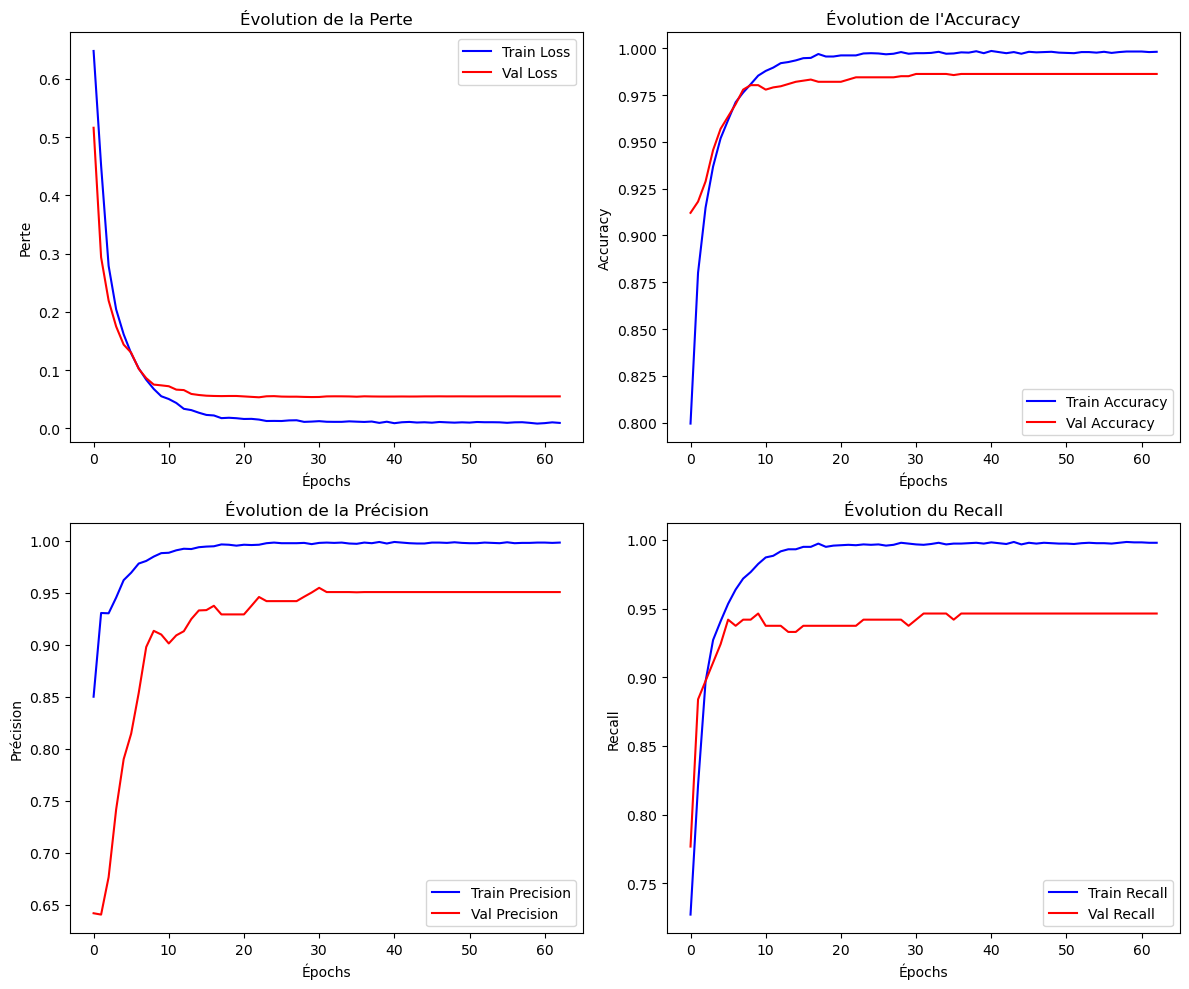

In [16]:
import matplotlib.pyplot as plt

# Récupération de l'historique de l'entraînement
history_dict = history.history

# Création des subplots
plt.figure(figsize=(12, 10))

# 🔹 1. Courbe de la perte (Loss)
plt.subplot(2, 2, 1)
plt.plot(history_dict["loss"], label="Train Loss", color="blue")
plt.plot(history_dict["val_loss"], label="Val Loss", color="red")
plt.xlabel("Épochs")
plt.ylabel("Perte")
plt.legend()
plt.title("Évolution de la Perte")

# 🔹 2. Courbe de l'accuracy
plt.subplot(2, 2, 2)
plt.plot(history_dict["accuracy"], label="Train Accuracy", color="blue")
plt.plot(history_dict["val_accuracy"], label="Val Accuracy", color="red")
plt.xlabel("Épochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Évolution de l'Accuracy")

# 🔹 3. Courbe de la Précision
plt.subplot(2, 2, 3)
plt.plot(history_dict["precision"], label="Train Precision", color="blue")
plt.plot(history_dict["val_precision"], label="Val Precision", color="red")
plt.xlabel("Épochs")
plt.ylabel("Précision")
plt.legend()
plt.title("Évolution de la Précision")

# 🔹 4. Courbe du Recall
plt.subplot(2, 2, 4)
plt.plot(history_dict["recall"], label="Train Recall", color="blue")
plt.plot(history_dict["val_recall"], label="Val Recall", color="red")
plt.xlabel("Épochs")
plt.ylabel("Recall")
plt.legend()
plt.title("Évolution du Recall")

# 🔥 Affichage des courbes
plt.tight_layout()
plt.show()


53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


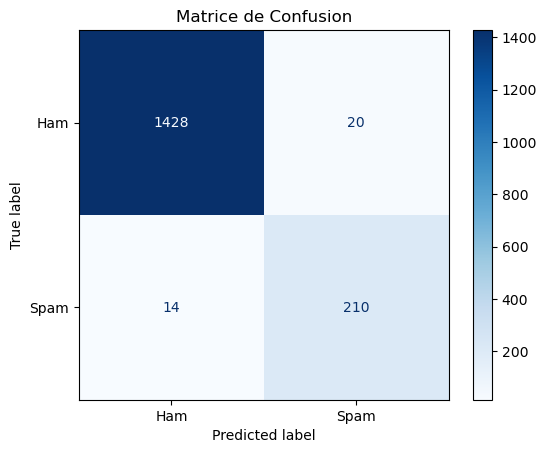

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99      1448
        Spam       0.91      0.94      0.93       224

    accuracy                           0.98      1672
   macro avg       0.95      0.96      0.96      1672
weighted avg       0.98      0.98      0.98      1672



In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Prédire les classes pour les données de validation
y_pred = model.predict(X_val_pad)
y_pred_classes = (y_pred > 0.5).astype(int)

# Calculer la matrice de confusion
cm = confusion_matrix(y_val, y_pred_classes)

# Afficher la matrice de confusion
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Ham", "Spam"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrice de Confusion")
plt.show()

# Calculer et afficher les métriques
print("Classification Report:")
print(classification_report(y_val, y_pred_classes, target_names=["Ham", "Spam"]))


In [18]:
import numpy as np

def predict_text(text, model, tokenizer, max_len):
    # Prétraitement du texte
    text_clean = ''.join(ch for ch in text if ch.isalnum() or ch == " " or ch == "'")
    text_clean = text_clean.replace(" +", " ").lower().strip()
    text_clean = " ".join([token.lemma_ for token in nlp(text_clean) if (token.lemma_ not in EN_STOP_WORDS) and (token.text not in EN_STOP_WORDS)])

    # Tokenization et padding
    text_encoded = tokenizer.texts_to_sequences([text_clean])
    text_padded = tf.keras.preprocessing.sequence.pad_sequences(text_encoded, maxlen=max_len, padding="post")

    # Prédiction
    prediction = model.predict(text_padded)

    # Affichage des résultats
    predicted_class = "SPAM" if prediction > 0.5 else "HAM"
    confidence_score = prediction[0][0] if predicted_class == "SPAM" else 1 - prediction[0][0]

    print(f"Text: {text}")
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence score: {confidence_score:.4f}")

# Exemple d'utilisation
text = "Hey Marty, we have a meeting tomorrow, don't forget it"
predict_text(text, model, tokenizer, X_train_pad.shape[1])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Text: Hey Marty, we have a meeting tomorrow, don't forget it
Predicted class: HAM
Confidence score: 0.9979


# Test sur Texts inventés pour l'occasion

In [19]:
import re
import emoji
import spacy
import tensorflow as tf
from spacy.lang.en.stop_words import STOP_WORDS as EN_STOP_WORDS

# Charger le modèle spaCy (une seule fois)
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def clean_text_spam_optimized(text):
    """Nettoie le texte en préservant les motifs de spam et en évitant les collisions de tags."""
    if not isinstance(text, str) or not text.strip():
        return ""

    text = re.sub(r"\s+", " ", text.strip())

    # 1. URLs raccourcies (avec/sans http://, et gestion des erreurs de syntaxe)
    text = re.sub(r"(?:https?://)?(?:bit\.ly|tinyurl\.com|goo\.gl|is\.gd|shor\.lu)/[a-zA-Z0-9]+", " <SHORTURL> ", text, flags=re.IGNORECASE)
    # 2. Autres URLs
    text = re.sub(r"https?://\S+|www\.\S+", " <URL> ", text, flags=re.IGNORECASE)

    # 3. Emails
    text = re.sub(r"\b[\w.-]+@[\w.-]+\.\w+\b", " <EMAIL> ", text)

    # 4. Numéros de téléphone
    text = re.sub(r"\b(?:\+?\d{1,3}[-. ]?)?\(?\d{3}\)?[-. ]?\d{3}[-. ]?\d{4}\b", " <PHONE> ", text)
    # 5. Nombres
    text = re.sub(r"\b\d+\b", " <NUM> ", text)

    # 6. Hashtags et mentions
    text = re.sub(r"#\w+", " <HASHTAG> ", text)
    text = re.sub(r"@\w+", " <MENTION> ", text)

    # 7. Mots-clés spam (liste étendue)
    spam_keywords = r"(?:urgent|immediate|now|asap|verify|confirm|claim|click\s*here|free|winner|prize|limited|offer|congratulations|guaranteed|win|won|congratulation|gift|money|grand|code|unlock|bank|account|compromised|login|security|alert)"
    text = re.sub(spam_keywords, " <SPAMKEY> ", text, flags=re.IGNORECASE)

    # 8. Redirections
    text = re.sub(r"(?:redirected|redirecting)\s*in\s*\d+\s*seconds", " <REDIRECT> ", text, flags=re.IGNORECASE)

    # 9. Emojis
    text = emoji.demojize(text)

    # 10. Caractères spéciaux utiles
    text = re.sub(r"[^\w\s'!\?\$#%&*+\-=@.|~`€£¥]", "", text)

    # 11. Normalisation finale des espaces
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

def lemmatize_pipe_spam(texts, batch_size=1000):
    """Lemmatise le texte en conservant les tags spéciaux."""
    out = []
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=1):
        tokens = [
            token.lemma_.lower() if token.text.lower() not in [
                "<url>", "<shorturl>", "<phone>", "<num>",
                "<email>", "<hashtag>", "<mention>", "<spamkey>", "<redirect>"
            ]
            else token.text.lower()
            for token in doc
            if (token.is_alpha or token.text.lower() in [
                "<url>", "<shorturl>", "<phone>", "<num>",
                "<email>", "<hashtag>", "<mention>", "<spamkey>", "<redirect>"
            ]) and not token.is_stop and token.text.strip() != ""
        ]
        out.append(" ".join(tokens))
    return out

def predict_text(text, model, tokenizer, max_len):
    """
    Prédit si un texte est du SPAM ou non, avec le même pipeline qu'à l'entraînement.
    Args:
        text (str): Texte brut à analyser.
        model: Modèle entraîné.
        tokenizer: Tokenizer utilisé pour l'entraînement.
        max_len (int): Longueur maximale des séquences.
    Returns:
        tuple: (classe prédite, score de confiance, texte nettoyé, texte lemmatisé)
    """
    # 1. Nettoyage
    text_clean = clean_text_spam_optimized(text)
    # 2. Lemmatisation
    text_lemmatized = lemmatize_pipe_spam([text_clean])[0]
    # 3. Tokenization et padding
    text_encoded = tokenizer.texts_to_sequences([text_lemmatized])
    text_padded = tf.keras.preprocessing.sequence.pad_sequences(text_encoded, maxlen=max_len, padding="post")
    # 4. Prédiction
    prediction = model.predict(text_padded, verbose=0)
    predicted_class = "SPAM" if prediction[0][0] > 0.5 else "HAM"
    confidence_score = prediction[0][0] if predicted_class == "SPAM" else 1 - prediction[0][0]
    return predicted_class, confidence_score, text_clean, text_lemmatized

# Liste de messages à tester
texts = [
    "Hey Marty, we have a meeting tomorrow, don't forget it",
    "You have won a $1000 Walmart gift card! Click here to claim now!",
    "Reminder: Your appointment with Dr. Smith is at 3 PM tomorrow.",
    "URGENT: Your bank account has been compromised. Verify your details immediately.",
    "Urgent: your banck account is compromised. Click here: http://bit.ly/xxx",
    "You have 1 unread message. Reply to unlock: bit.ly/msg123",
    "Security alert: suspicious login from NY. Confirm now: verify-link.com",
    "FREE MONEY! CLAIM YOUR PRIZE NOW! NO LIMIT!",
    "Hello, can we meet tomorrow?",
    "Congratulation, you've won an iphone, clic here now to grab it!",
    "Hello, do we have a meeting today ? Could you call me?",
    "Your just won 500 buck, claim it now, clic here !",
    "Charles, let's work together on this projet.",
    "Hello Aline, why don't you answer to my call ?",
    "Eric, could you schedule a meeting for next week.",
    "Maybe the false negatif is to high. We should improve it.",
    "We are please to announce that you have won an iphone 16, click here : http:shor.lu/122",
    "We offer you 10 grands for you effort. It's a not a big deal for us. Thank you",
    "Your verification code is 123456. Do not share it with anyone.",
    "Hello Eric, i have your answer, call me asap."
]

# Boucle pour tester chaque message
for text in texts:
    predicted_class, confidence_score, cleaned, lemmatized = predict_text(text, model, tokenizer, X_train_pad.shape[1])
    print(f"Text: {text}")
    print(f"Cleaned: {cleaned}")
    print(f"Lemmatized: {lemmatized}")
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence score: {confidence_score:.4f}\n")


Text: Hey Marty, we have a meeting tomorrow, don't forget it
Cleaned: hey marty we have a meeting tomorrow don't forget it
Lemmatized: hey marty meeting tomorrow forget
Predicted class: HAM
Confidence score: 0.9979

Text: You have won a $1000 Walmart gift card! Click here to claim now!
Cleaned: you have spamkey a $ num walmart spamkey card! spamkey to spamkey spamkey !
Lemmatized: spamkey num walmart spamkey card spamkey spamkey spamkey
Predicted class: SPAM
Confidence score: 0.9932

Text: Reminder: Your appointment with Dr. Smith is at 3 PM tomorrow.
Cleaned: reminder your appointment with dr. smith is at num pm tomorrow.
Lemmatized: reminder appointment dr smith num pm tomorrow
Predicted class: HAM
Confidence score: 0.9313

Text: URGENT: Your bank account has been compromised. Verify your details immediately.
Cleaned: spamkey your spamkey spamkey has been spamkey . spamkey your details spamkey ly.
Lemmatized: spamkey spamkey spamkey spamkey spamkey detail spamkey ly
Predicted class: 

In [20]:
import re

def predict_text(text, model, tokenizer, max_len):
    # Utiliser le même nettoyage que clean_text_spam_optimized
    text_clean = clean_text_spam_optimized(text)  # Appelle ta fonction existante

    # Tokenization et padding (identique à avant)
    text_encoded = tokenizer.texts_to_sequences([text_clean])
    text_padded = tf.keras.preprocessing.sequence.pad_sequences(text_encoded, maxlen=max_len, padding="post")

    # Prédiction
    prediction = model.predict(text_padded)

    # Résultats
    predicted_class = "SPAM" if prediction > 0.5 else "HAM"
    confidence_score = prediction[0][0] if predicted_class == "SPAM" else 1 - prediction[0][0]
    return predicted_class, confidence_score


# Test sur Textes inventés pour l'occasion

In [125]:
import re
import emoji
import spacy
import tensorflow as tf

# Charger le modèle spaCy (assure-toi qu'il est installé : python -m spacy download en_core_web_sm)
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def clean_text_spam_optimized(text):
    """Nettoie le texte en préservant les motifs de spam."""
    if not isinstance(text, str) or not text.strip():
        return ""
    text = re.sub(r"\s+", " ", text.strip())
    # URLs raccourcies
    text = re.sub(r"http[s]?://(?:bit\.ly|tinyurl\.com|goo\.gl|is\.gd|shor\.lu)/[a-zA-Z0-9]+", " <SHORTURL> ", text)
    # URLs classiques
    text = re.sub(r"http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+", " <URL> ", text)
    # Emails
    text = re.sub(r"\b[\w.-]+@[\w.-]+\.\w+\b", " <EMAIL> ", text)
    # Numéros de téléphone
    text = re.sub(r"\b(?:\+?\d{1,3}[-. ]?)?\(?\d{3}\)?[-. ]?\d{3}[-. ]?\d{4}\b", " <PHONE> ", text)
    # Hashtags et mentions
    text = re.sub(r"#\w+", " <HASHTAG> ", text)
    text = re.sub(r"@\w+", " <MENTION> ", text)
    # Mots-clés spam
    spam_keywords = r"(?:urgent|immediate|now|asap|verify|confirm|claim|click\s*here|free|winner|prize|limited|offer|congratulations|guaranteed)"
    text = re.sub(spam_keywords, " <SPAMKEY> ", text, flags=re.IGNORECASE)
    # Redirections
    text = re.sub(r"(?:redirected|redirecting)\s*in\s*\d+\s*seconds", " <REDIRECT> ", text, flags=re.IGNORECASE)
    # Emojis
    text = emoji.demojize(text)
    # Caractères spéciaux utiles
    text = re.sub(r"[^\w\s'!\?\$#%&*+\-=@.|~`€£¥]", "", text)
    # Nombres
    text = re.sub(r"\b\d+\b", lambda m: "<NUM>" if len(m.group()) > 1 else m.group(), text)
    # Normalisation finale
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text

def lemmatize_pipe_spam(texts, batch_size=100):
    """Lemmatise le texte en conservant les tags spéciaux."""
    out = []
    for doc in nlp.pipe(texts, batch_size=batch_size, n_process=1):
        tokens = [
            token.lemma_.lower() if token.text.lower() not in ["<url>", "<shorturl>", "<phone>", "<num>", "<redirect>", "<email>", "<hashtag>", "<mention>", "<spamkey>"] else token.text.lower()
            for token in doc
            if (token.is_alpha or token.text.lower() in ["<url>", "<shorturl>", "<phone>", "<num>", "<redirect>", "<email>", "<hashtag>", "<mention>", "<spamkey>"]) and not token.is_stop and token.text.strip() != ""
        ]
        out.append(" ".join(tokens))
    return out

def predict_text(text, model, tokenizer, max_len):
    """
    Prédit si un texte est du SPAM ou non, en appliquant le même pipeline qu'à l'entraînement.

    Args:
        text (str): Texte brut à analyser.
        model: Modèle entraîné.
        tokenizer: Tokenizer utilisé pour l'entraînement.
        max_len (int): Longueur maximale des séquences.

    Returns:
        tuple: (classe prédite, score de confiance)
    """
    # 1. Nettoyage
    text_clean = clean_text_spam_optimized(text)
    # 2. Lemmatisation (identique à l'entraînement)
    text_lemmatized = lemmatize_pipe_spam([text_clean])[0]
    # 3. Tokenization et padding
    text_encoded = tokenizer.texts_to_sequences([text_lemmatized])
    text_padded = tf.keras.preprocessing.sequence.pad_sequences(text_encoded, maxlen=max_len, padding="post")
    # 4. Prédiction
    prediction = model.predict(text_padded, verbose=0)
    predicted_class = "SPAM" if prediction[0][0] > 0.5 else "HAM"
    confidence_score = prediction[0][0] if predicted_class == "SPAM" else 1 - prediction[0][0]
    return predicted_class, confidence_score, text_clean, text_lemmatized

# Exemple d'utilisation
texts = [
"Hey Marty, we have a meeting tomorrow, don't forget it",
    "You have won a $1000 Walmart gift card! Click here to claim now!",
    "Reminder: Your appointment with Dr. Smith is at 3 PM tomorrow.",
    "URGENT: Your bank account has been compromised. Verify your details immediately.",
    "Urgent: your banck account is compromised. Click here: http://bit.ly/xxx",
    "You have 1 unread message. Reply to unlock: http://bit.ly/msg123",
    "Security alert: suspicious login from NY. Confirm now: verify-link.com",
    "FREE MONEY! CLAIM YOUR PRIZE NOW! NO LIMIT!",
    "Hello, can we meet tomorrow?",
    "Congratulation, you've won an iphone, clic here now to grab it!",
    "Hello, do we have a meeting today ? Could you call me?",
    "Your just won 500 buck, claim it now, clic here !",
    "Charles, let's work together on this projet.",
    "Hello Aline, why don't you answer to my call ?",
    "Eric, could you schedule a meeting for next week.",
    "Maybe the false negatif is to high. We should improve it.",
    "We are please to announce that you have won an iphone 16, click here : http://short.lu/122",
    "We offer you 10 grands for you effort. It's a not a big deal for us. Thank you",
    "Your verification code is 123456. Do not share it with anyone.",
    "Hello Eric, i have your answer, call me asap."
]

for text in texts:
    predicted_class, confidence_score, cleaned, lemmatized = predict_text(text, model, tokenizer, X_train_pad.shape[1])
    print(f"Text: {text}")
    print(f"Cleaned: {cleaned}")
    print(f"Lemmatized: {lemmatized}")
    print(f"Predicted class: {predicted_class}")
    print(f"Confidence score: {confidence_score:.4f}\n")


Text: Hey Marty, we have a meeting tomorrow, don't forget it
Cleaned: hey marty we have a meeting tomorrow don't forget it
Lemmatized: hey marty meeting tomorrow forget
Predicted class: HAM
Confidence score: 0.9982

Text: You have won a $1000 Walmart gift card! Click here to claim now!
Cleaned: you have won a $<num> walmart gift card! spamkey to spamkey spamkey !
Lemmatized: win num walmart gift card spamkey spamkey spamkey
Predicted class: SPAM
Confidence score: 0.9590

Text: Reminder: Your appointment with Dr. Smith is at 3 PM tomorrow.
Cleaned: reminder your appointment with dr. smith is at 3 pm tomorrow.
Lemmatized: reminder appointment dr smith pm tomorrow
Predicted class: HAM
Confidence score: 0.9952

Text: URGENT: Your bank account has been compromised. Verify your details immediately.
Cleaned: spamkey your bank account has been compromised. spamkey your details spamkey ly.
Lemmatized: spamkey bank account compromise spamkey detail spamkey ly
Predicted class: SPAM
Confidence sco